# 📊 统计与密度图 — 直方图 / 等高线

**对应章节:** 04.04 Density and Contour Plots · 04.05 Histograms, Binnings, and Density

---

## 📖 学到进度 ⚪ 未开始

`░░░░░░░░░░░░░░░░░░░░` 0%

**数据文件:** `../data/` 目录下对应数据

**提示:** 在 `# ---- 开始 ----` 和 `# ---- 结束 ----` 之间填写代码

---


## ✏️ 练习 2-1: 直方图

📘 04.05 Histograms, Binnings, and Density

数据: 鸢尾花花瓣长度

**要求:**
- 20 个 bins
- 颜色天蓝色 'skyblue', 边缘黑色
- 透明度 0.7
- 添加垂直线标注平均值 (红色虚线)

💡 *提示: np.loadtxt(..., usecols=2)*

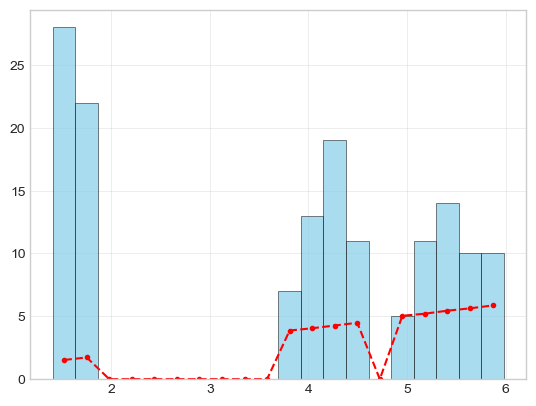

In [40]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')
data = np.loadtxt('../data/flower_measurements.csv', delimiter=',', skiprows=1, usecols=2)
# ---- 开始 ----
plt.hist(data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
counts, bin_edge = np.histogram(data, bins=20)
x = (bin_edge[:-1] + bin_edge[1:])/2 # 不取最后一个+不取第一个
data_sort = np.sort(data)
y = np.zeros(len(counts))
k = 0
for i in range(0, len(counts)):
    temp = 0
    for j in range(0, counts[i]):
        temp = temp + data_sort[k]
        k = k + 1
    if counts[i] > 0:
        y[i] = temp / counts[i]
    else:
        y[i] = 0

# 等价于:
# bins_data = np.split(data_sorted, np.cumsum(counts)[:-1])
# y = np.array([b.mean() for b in bins_data if len(b) > 0])
plt.plot(x, y, '--.r')
plt.show;
# ---- 结束 ----

## ✏️ 练习 2-2: 二维直方图 (hexbin)

📘 04.05 Histograms, Binnings, and Density

数据: 鸢尾花花瓣长 vs 花瓣宽

**要求:**
- 用 plt.hexbin, gridsize=30
- 颜色映射 'viridis'
- 添加颜色条 (plt.colorbar)
- x/y轴标签: Petal Length, Petal Width

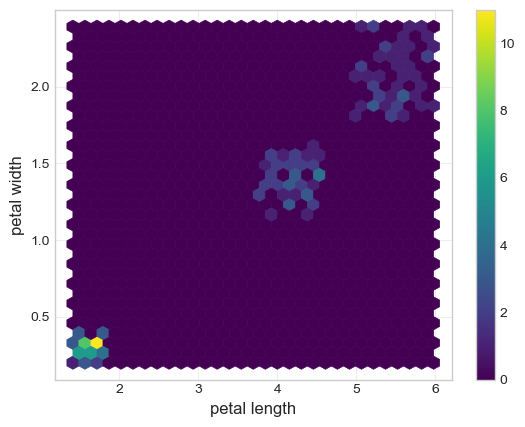

In [46]:
all_data = np.loadtxt('../data/flower_measurements.csv', delimiter=',', skiprows=1, usecols=(2, 3))
petal_length = all_data[:, 0]; petal_width = all_data[:, 1]
# ---- 开始 ----
plt.hexbin(petal_length, petal_width, gridsize=30, cmap='viridis')
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.colorbar()
plt.show();
# ---- 结束 ----

## ✏️ 练习 2-3: 等高线图

📘 04.04 Density and Contour Plots

数据: 50×50 网格数据

**要求:**
- 用 plt.contour, 20 条等高线
- 颜色映射 'RdYlBu'
- 再用 plt.contourf 填充, 透明度 0.5
- 叠加 plt.clabel

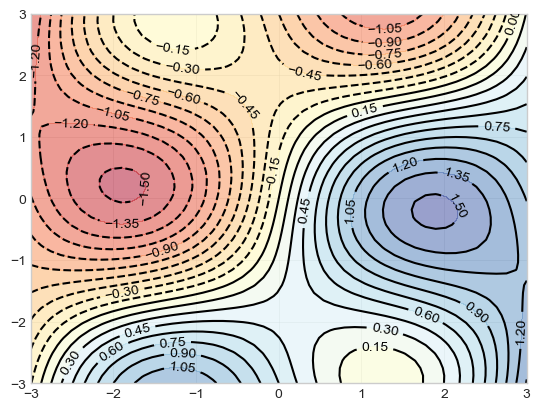

In [45]:
grid = np.loadtxt('../data/grid_data.csv', delimiter=',', skiprows=1)
X = grid[:, 0].reshape(50, 50); Y = grid[:, 1].reshape(50, 50); Z = grid[:, 2].reshape(50, 50)
# ---- 开始 ----
contours = plt.contour(X, Y, Z, 20, colors='black')
plt.clabel(contours, inline=True, fontsize=10)
plt.contourf(X, Y, Z, 20, cmap='RdYlBu', alpha=0.5);
# ---- 结束 ----

## 🌟 练习 2-4: imshow 热力图 (选做)

📘 04.04 Density and Contour Plots

直接用 plt.imshow 显示 Z 数据, cmap='coolwarm', 插值='bilinear'

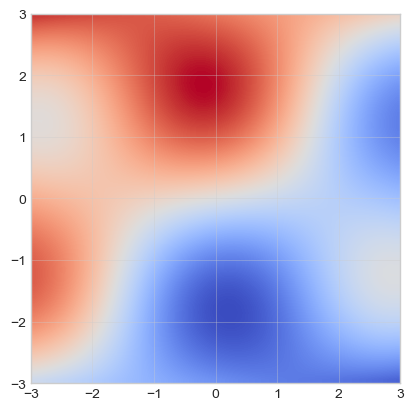

In [43]:
# ---- 开始 ----
plt.imshow(Z, extent=(X.min(),X.max(),Y.min(),Y.max()), aspect='equal', origin='lower', cmap='coolwarm', interpolation='bilinear');
# ---- 结束 ----

---

## 📌 三类统计/密度图总结

| 类别 | 函数 | 输入 | 需要 meshgrid？ | 本质 |
|------|------|------|:---:|------|
| **第一类：统计分箱** | `hist` / `hist2d` / `hexbin` | 原始数据点 | ❌ 不需要 | 数每个区域有几个点 |
| **第二类：像素渲染** | `imshow` | 2D 矩阵 Z | ❌（自动索引） | 把矩阵值直接映射为颜色 |
| **第三类：等高线插值** | `contour` / `contourf` | 网格 X, Y, Z | ✅ **必须** | 在网格间插值画连续线/填充 |

### 快速口诀

> **原始点 → hist / hexbin / hist2d**（统计有几个）
> **已有矩阵 → imshow**（直接贴图）
> **网格 + 函数值 → contour / contourf**（画等高线）

### 一个容易踩的坑

```python
# ❌ 错误：hexbin 传了 meshgrid 的结果
Xgrid, Ygrid = np.meshgrid(x, y)
plt.hexbin(Xgrid, Ygrid)   # 数据被变成了 N×N 个假点

# ✅ 正确：hexbin 要原始点
plt.hexbin(x, y)   # x, y 是原始数据，不用 meshgrid
```